In [ ]:
pip install ultralytics transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 24.9 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
from ultralytics import YOLOWorld
import cv2
import numpy as np
from google.colab.patches import cv2_imshow

# Load a pre-trained YOLO-World model
# Options: 'yoloworld/yoloworld-v2-s', 'yoloworld/yoloworld-v2-m', 'yoloworld/yoloworld-v2-l'
# 's' for small (fastest), 'm' for medium, 'l' for large (most accurate, slower)
model = YOLOWorld('yolov8s-worldv2.pt') # Start with 's' for speed, adjust if needed

# Define the objects you want to detect using text prompts
# These can be ANYTHING, even if the model wasn't specifically trained on them.
# For your project, this is where you'd specify 'product' and 'reference_object'
# but you can also add other items for demonstration.
custom_classes = ["product", "coin", "credit card", "shipping box", ""]

# Set the classes for the model
model.set_classes(custom_classes)

# Path to your input image
image_path = "/content/drive/MyDrive/Labeled_data12/train/images/test114.jpg"

# Perform inference
results = model(image_path, conf=0.1)

# Process and display results
for r in results:
    im_bgr = r.plot() # Get the annotated image (BGR format for OpenCV)

    # You can also access raw detection data:
    for box, cls_id, conf in zip(r.boxes.xyxy, r.boxes.cls, r.boxes.conf):
        class_name = model.names[int(cls_id)]
        x1, y1, x2, y2 = map(int, box)
        confidence = float(conf)

        print(f"Detected: {class_name}, Confidence: {confidence:.2f}, Bounding Box: [{x1}, {y1}, {x2}, {y2}]")

        # Draw on image using OpenCV (optional, r.plot() already does this)
        # cv2.rectangle(im_bgr, (x1, y1), (x2, y2), (0, 255, 0), 2)
        # cv2.putText(im_bgr, f'{class_name} {confidence:.2f}', (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)

# Display the image with detections
cv2_imshow(im_bgr)

# Save the annotated image (optional)
# cv2.imwrite("output_image_yoloworld.jpg", im_bgr)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
requirements: Ultralytics requirement ['git+https://github.com/ultralytics/CLIP.git'] not found, attempting AutoUpdate...
Using Python 3.12.12 environment at: /usr
Resolved 34 packages in 735ms
Prepared 2 packages in 2.31s
Installed 2 packages in 1ms
 + clip==1.0 (from git+https://github.com/ultralytics/CLIP.git@19870eafbf315e6bfbc73fc97935abbd83924416)
 + ftfy==6.3.1

requirements: AutoUpdate success ✅ 3.4s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect



 39%|███████████████▏                       | 131M/338M [00:02<00:04, 51.1MiB/s]


KeyboardInterrupt: 

In [ ]:
# Create the data.yaml file directly in the current directory

%%writefile data.yaml
# data.yaml
# -------------------------------------------------------------

# IMPORTANT: REPLACE THE LINE BELOW WITH THE ACTUAL PATH TO YOUR
# /smart_packaging_data FOLDER IN GOOGLE DRIVE OR YOUR COLAB FILES.
# Example path if your data is in Google Drive:
path: /content/drive/MyDrive/Labeled_data12

# Define the paths for your training and validation image sets
# These paths are RELATIVE to the 'path' defined above.
train: train/images
val: val/images

# Number of classes
nc: 2

# Class names in the correct zero-indexed order
names: ['product', 'reference_object']

Writing data.yaml


In [ ]:
import torch
from ultralytics import YOLOWorld

# -------------------------------------------------------------
# 1. Configuration
# -------------------------------------------------------------

# Use the 'medium' model for better small object detection than 'small',
# as coins/cards are small. It will auto-download the weights.
MODEL_WEIGHTS = 'yolov8m-worldv2.pt'

# The path to the data.yaml file you just created.
DATA_YAML_PATH = '/content/drive/MyDrive/Labeled_data12/data.yaml'

# -------------------------------------------------------------
# 2. Model Loading and Setup
# -------------------------------------------------------------

# Load the pre-trained YOLO-World model
model = YOLOWorld(MODEL_WEIGHTS)

# -------------------------------------------------------------
# 3. Start Fine-Tuning with Optimized Hyperparameters
# -------------------------------------------------------------

print(f"Starting YOLO-World Fine-Tuning on {MODEL_WEIGHTS}...")

results = model.train(
    data=DATA_YAML_PATH,
    epochs=100,         # Start with 100 epochs. Monitor for overfitting (Validation Loss increases).
    imgsz=1024,         # CRITICAL: Increased resolution improves small object (coin/card) detection.
    batch=4,            # Smaller batch size is necessary for high resolution (1024) and limited GPU memory (common in Colab).
    name='smart_pkg_finetune_1024',
    device='cuda' if torch.cuda.is_available() else 'cpu', # Use GPU if available

    # Hyperparameters for Small Dataset/Fine-Tuning
    lr0=0.001,          # Lower initial learning rate to prevent large changes to the pre-trained weights.
    patience=50,        # Stop training early if no improvement in 50 epochs to prevent overfitting.
    close_mosaic=10,    # Disable the aggressive Mosaic data augmentation for the last 10 epochs to stabilize training.

    # Data Augmentation for Robustness (adjust these if performance is poor)
    hsv_s=0.5,          # High saturation/value changes simulate various lighting conditions.
    degrees=5.0,        # Small rotation
    perspective=0.0002  # Tiny bit of perspective distortion
)

print("Fine-Tuning Complete! Model weights saved in the 'runs' folder.")

# After training, you can validate the model:
# metrics = model.val()
# print(f"Validation mAP50-95: {metrics.box.map}")

Starting YOLO-World Fine-Tuning on yolov8m-worldv2.pt...
Ultralytics 8.3.233 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/Labeled_data12/data.yaml, degrees=5.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.5, hsv_v=0.4, imgsz=1024, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8m-worldv2.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=smart_pkg_finetune_10242, nbs=64, nms=False, opset=None

/usr/local/lib/python3.12/dist-packages/clip/clip.py:64: UserWarning: /root/.cache/clip/ViT-B-32.pt exists, but the SHA256 checksum does not match; re-downloading the file
  warnings.warn(f"{download_target} exists, but the SHA256 checksum does not match; re-downloading the file")
100%|███████████████████████████████████████| 338M/338M [00:06<00:00, 52.1MiB/s]


Image sizes 1024 train, 1024 val
Using 2 dataloader workers
Logging results to /content/runs/detect/smart_pkg_finetune_10242
Starting training for 100 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
      1/100      4.41G      1.226      3.635        1.6         14       1024: 43% ━━━━━─────── 13/30 2.3it/s 9.5s<7.5s


KeyboardInterrupt: 


image 1/1 /Users/umairmomin/Desktop/Smart Packaging/Labeled_data12/train/images/test126.jpg: 1024x768 1 product, 1 reference_object, 679.1ms
Speed: 5.2ms preprocess, 679.1ms inference, 1.2ms postprocess per image at shape (1, 3, 1024, 768)
Results saved to /Users/umairmomin/Desktop/Smart Packaging/runs/detect/predict2

Inference Complete. Results saved to: /Users/umairmomin/Desktop/Smart Packaging/runs/detect/predict2


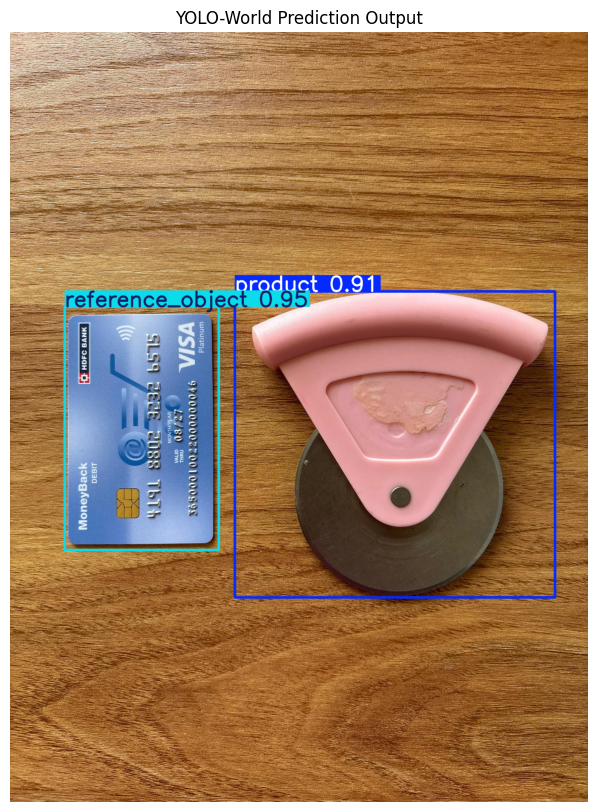

In [4]:
import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLOWorld

# IMPORTANT: Use the same WEIGHTS_PATH as above.
# WEIGHTS_PATH = 'best.pt'
WEIGHTS_PATH = 'best.pt'

# Path to a single test image or a folder of test images (e.g., your validation set)
TEST_IMAGE_PATH = 'Labeled_data12/train/images/test126.jpg'

# Load the trained model
model = YOLOWorld(WEIGHTS_PATH)

# Run inference
# Set the 'conf' lower (e.g., 0.2) to see all detections, even lower-confidence ones.
results = model.predict(source=TEST_IMAGE_PATH, conf=0.2, imgsz=1024, save=True)

print(f"\nInference Complete. Results saved to: {results[0].save_dir}")

# Display the first image result (using Matplotlib for Colab)
if results:
    im_bgr = results[0].plot() # Get the annotated image (BGR format)
    img_rgb = cv2.cvtColor(im_bgr, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(12, 10))
    plt.imshow(img_rgb)
    plt.title("YOLO-World Prediction Output")
    plt.axis('off')
    plt.show()

In [ ]:
import torch
from ultralytics import YOLOWorld

# -------------------------------------------------------------
# 1. Configuration
# -------------------------------------------------------------
# Use the BEST.PT from your previous run for continued fine-tuning
WEIGHTS_PATH = '/content/drive/MyDrive/Labeled_data12/best.pt'
DATA_YAML_PATH = '/content/drive/MyDrive/Labeled_data12/data.yaml'

# -------------------------------------------------------------
# 2. Model Loading and Setup
# -------------------------------------------------------------
# Load the already fine-tuned weights
model = YOLOWorld(WEIGHTS_PATH)

# -------------------------------------------------------------
# 3. Start RERUN with Generalization & Precision Tuning
# -------------------------------------------------------------
print("Starting Phase 2 Fine-Tuning for Generalization...")

results = model.train(
    data=DATA_YAML_PATH,
    epochs=50,          # Start with fewer epochs; you are already close to optimal.
    imgsz=1024,         # Keep high resolution
    batch=4,            # Keep batch size small
    name='smart_pkg_generalize_phase2',
    device='cuda' if torch.cuda.is_available() else 'cpu',

    # HYPERPARAMETERS TUNED FOR GENERALIZATION & PRECISION
    lr0=0.0005,         # Very low learning rate for subtle adjustments
    patience=25,        # Early stopping patience
    iou=0.7,            # INCREASE IoU threshold for better localization
    box=0.05,           # INCREASE weight on the box localization loss

    # AGGRESSIVE AUGMENTATION for Unseen Products
    hsv_s=0.8,          # Increased Saturation
    hsv_v=0.8,          # Increased Value/Brightness
    perspective=0.001,  # Slight Perspective
    shear=0.2,          # Increased Shear
    degrees=10.0,       # Increased Rotation
)

print("Phase 2 Complete!")

Starting Phase 2 Fine-Tuning for Generalization...
Ultralytics 8.3.233 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=0.05, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/Labeled_data12/data.yaml, degrees=10.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.8, hsv_v=0.8, imgsz=1024, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0005, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/content/drive/MyDrive/Labeled_data12/best.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=smart_pkg_generalize_phase2, nbs